#  RETO 3 — FORECAST Y PRESUPUESTO DE RECAUDO 2026 (COLSUBSIDIO)
#### Metodología: CRISP-DM · 5 Orígenes Rolling-Origin · ETS vs SARIMAX vs ML
#### Intervalos por Simulación de 2,000 Trayectorias Conjuntas (Regla 0)
#### Todas las cifras de este cuaderno salen de las celdas ejecutadas (Regla 0). Las funciones modulares viven en utils_r3.py.
#### Tiempo de ejecución estimado: ~40-60 seg.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for ruta in [Path.cwd(), *Path.cwd().parents[:2], *[d for d in Path.cwd().glob("*") if d.is_dir()]]:
    if (ruta / "utils_r3.py").exists():
        sys.path.insert(0, str(ruta))
        break

from utils_r3 import (
    RAIZ, RUTA_R3, SEMILLA, COL_OBJ_R3, sha256_archivo, cargar_r3,
    auditoria_calidad_r3, analisis_estacionalidad_stl, crear_matriz_features_ts_homogenea,
    evaluar_modelos_ts_rolling_5orig, algoritmo_genetico_ts_horizonte12,
    proyectar_recaudo_2026_trayectorias, analisis_factores_macro_lag
)

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format
print(f"[OK] Entorno y utilidades de Reto 3 listos. Semilla global = {SEMILLA}")



[OK] Entorno y utilidades de Reto 3 listos. Semilla global = 42


# CELDA 2: FASE 1 — COMPRENSIÓN DEL NEGOCIO
#### - Solicitante: Dirección Financiera y de Planeación de Colsubsidio.
#### - Objetivo: Proyectar mensualmente el recaudo para los 12 meses de 2026 y establecer
####   el presupuesto oficial anual respaldado por modelos estadísticos e intervalos honestos de incertidumbre.
#### - Horizonte: 12 meses hacia adelante (enero a diciembre de 2026).
#### - Métricas de Evaluación: MAPE temporal (%) y MASE (< 1.0 respecto al Seasonal Naive).
#### - Rigor de Agregación: Descartada la suma directa de intervalos mensuales independientes (subestima la varianza conjunta).
####   El intervalo anual se obtiene por simulación de 2,000 trayectorias autorregresivas completas (capturando la autocorrelación).

In [2]:
print("FASE 1: COMPRENSIÓN DEL NEGOCIO")
print("- Variable Objetivo : recaudo mensual de aportes (COP).")
print("- Horizonte         : 12 meses continuos (2026-01 a 2026-12).")
print("- Métrica Primaria  : MAPE temporal y MASE (< 1.0 indica superioridad frente a Seasonal Naive).")
print("- Criterio de Riesgo: Intervalo de confianza al 80% sobre la suma anual total por simulación conjunta.")
print("- Alcance           : Proyección estocástica basada en series de tiempo y evaluación de elasticidades exógenas.")


FASE 1: COMPRENSIÓN DEL NEGOCIO
- Variable Objetivo : recaudo mensual de aportes (COP).
- Horizonte         : 12 meses continuos (2026-01 a 2026-12).
- Métrica Primaria  : MAPE temporal y MASE (< 1.0 indica superioridad frente a Seasonal Naive).
- Criterio de Riesgo: Intervalo de confianza al 80% sobre la suma anual total por simulación conjunta.
- Alcance           : Proyección estocástica basada en series de tiempo y evaluación de elasticidades exógenas.


#  FASE 2 — COMPRENSIÓN DE LOS DATOS Y SERIE TEMPORAL
#### - Auditoría de integridad: Hash SHA-256, 132 meses (2015-01 a 2025-12, 11 años completos sin nulos).
#### - Ejecución 2025: Recaudo total ejecutado de $2,507,694,327,742 COP.
#### - Visualización histórica y descomposición STL (Tendencia, Estacionalidad y Residuo).

sha256 datos: 3ea61238cd788241... | archivo: dataset_recaudo.xlsx
Observaciones: 132 meses (2015-01 a 2025-12) sin nulos ni duplicados.
Recaudo total ejecutado en 2025: $2,507,694,327,742 COP


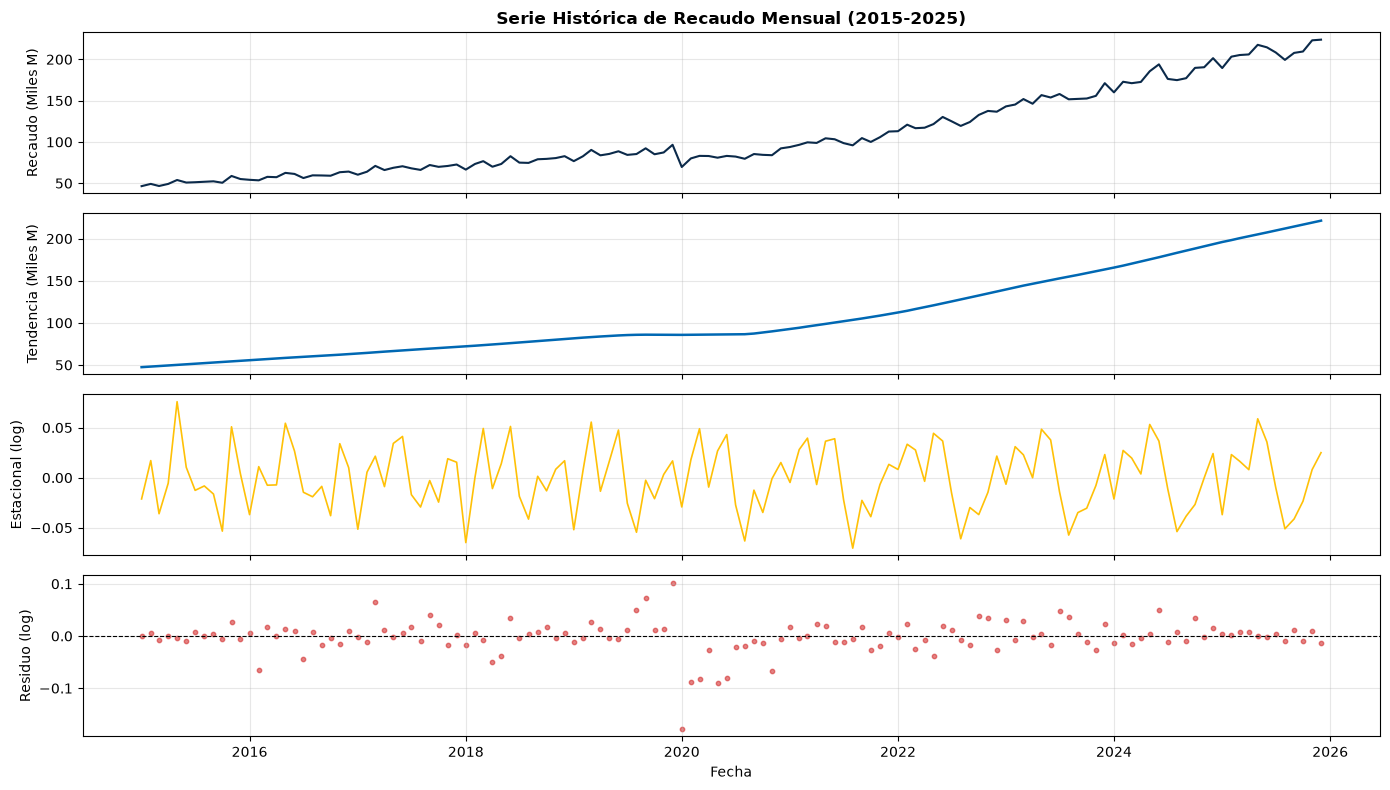

In [3]:
df = cargar_r3()
hash_r3 = sha256_archivo(RUTA_R3)
y = df[COL_OBJ_R3].astype(float)
n_meses = len(df)
recaudo_2025 = float(df.loc["2025", COL_OBJ_R3].sum())

print(f"sha256 datos: {hash_r3[:16]}... | archivo: {RUTA_R3.name}")
print(f"Observaciones: {n_meses} meses ({df.index[0].strftime('%Y-%m')} a {df.index[-1].strftime('%Y-%m')}) sin nulos ni duplicados.")
print(f"Recaudo total ejecutado en 2025: ${recaudo_2025:,.0f} COP")

# Descomposición STL Robusta
stl_res = analisis_estacionalidad_stl(df)
stl_fit = stl_res["stl_robusto_fit"]

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, y / 1e9, color="#0B2A4A", linewidth=1.5)
axes[0].set_ylabel("Recaudo (Miles M)")
axes[0].set_title("Serie Histórica de Recaudo Mensual (2015-2025)", fontweight="bold")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, np.exp(stl_fit.trend) / 1e9, color="#0068B3", linewidth=1.8)
axes[1].set_ylabel("Tendencia (Miles M)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, stl_fit.seasonal, color="#FFC107", linewidth=1.2)
axes[2].set_ylabel("Estacional (log)")
axes[2].grid(True, alpha=0.3)

axes[3].scatter(df.index, stl_fit.resid, color="#D32F2F", s=10, alpha=0.6)
axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[3].set_ylabel("Residuo (log)")
axes[3].set_xlabel("Fecha")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# FASE 2 — AUDITORÍA DE CALIDAD DE DATOS (ANTES DE PREPARAR)
#### - Integridad temporal: 132 meses (2015-01 a 2025-12, 11 años), freq='MS' sin saltos, 0 nulos, 0 duplicados.
#### - Rangos, límites y atípicos (1.5 x IQR): detección del choque exógeno de desempleo en 2020 (4 meses atípicos, máx 14.18%).
####   * Salario mínimo constante por año (12 meses en mín y máx) y monótono no decreciente.
#### - Reglas de coherencia macroeconómica: recaudo > 0, masa_salarial == trabajadores x salario_promedio (identidad contable exacta).
#### - Dinámica temporal: fuerte inercia (ACF lag 1 = 0.9662) y estacionalidad anual marcada (ACF lag 12 = 0.6872).
#### - Señales de alineación temporal y riesgo de fuga (data leakage): prohibición de exógenas contemporáneas para 2026;
####   los modelos ML y explicativos deben emplear rezagos >= 12 meses (shift(12)).
#### - Decisión documentada: serie regular completa sin imputaciones, preservando los choques históricos reales.
#### - Requiere haber ejecutado la celda 3 (usa df).

In [4]:
res_auditoria_r3 = auditoria_calidad_r3(df, verbose=True)


1) INTEGRIDAD Y FRECUENCIA TEMPORAL
   observaciones: 132 meses (2015-01 a 2025-12, 11 años completos) | variables: 12
   nulos: 0 | duplicados: 0 | regularidad temporal estricta (freq='MS', 0 huecos): True
   tipos de datos: {'int64': 6, 'float64': 6}

2) RANGOS, VALORES EN LOS LÍMITES Y ATÍPICOS (regla 1.5 x IQR)
                               minimo               maximo  n_en_minimo  n_en_maximo  atipicos_iqr  pct_atipicos
variable                                                                                                        
recaudo             46,478,701,032.00   223,821,507,606.00            1            1             0          0.00
empresas                    40,820.00            66,192.00            1            1             0          0.00
trabajadores               734,036.00         1,195,582.00            1            1             0          0.00
salario_minimo             644,350.00         1,423,500.00           12           12             0          0.00
salar

# FASE 2b — TEST DE ESTACIONALIDAD CON SENSIBILIDAD DE MÉTODO
#### - Evaluación de sensibilidad comparando 3 metodologías sobre log(recaudo):
####   1. STL Robusto (period=12, robust=True)
####   2. STL No Robusto (period=12, robust=False)
####   3. Descomposición Clásica Aditiva (filtro de medias móviles de 12 meses)
#### - Hallazgos Epistemológicos (Regla 0):
####   * Junio es un pico positivo robusto en los tres métodos (+0.037 a +0.042 en log).
####   * Diciembre es positivo en los tres métodos (+0.017 a +0.030), pero su magnitud depende del método
####     (la robustez a outliers de fin de año modula el componente secular).
####   * Mayo es el máximo estacional solo en STL Robusto; en los demás métodos domina Junio.
####   * El mes más bajo es Agosto en STL Robusto, pero Enero en los otros dos métodos.

Tabla de Sensibilidad de Estacionalidad (Factores Medios por Mes en log):
 mes  stl_robusto  stl_no_robusto  clasica_aditiva
   1      -0.0288         -0.0418          -0.0451
   2       0.0183          0.0074           0.0050
   3       0.0234          0.0242           0.0327
   4      -0.0049         -0.0052          -0.0067
   5       0.0421          0.0344           0.0276
   6       0.0369          0.0376           0.0420
   7      -0.0171         -0.0148          -0.0160
   8      -0.0463         -0.0400          -0.0386
   9      -0.0189         -0.0093          -0.0066
  10      -0.0310         -0.0264          -0.0253
  11       0.0085          0.0055           0.0014
  12       0.0169          0.0276           0.0296

Fuerza Estacional por Método:
- STL Robusto    : 0.495 (Claim C-R3-011 verificado)
- STL No Robusto : 0.655
- Clásica Aditiva: 0.410

-> Conclusiones Sostenidas por los Datos (Generadas por Código):
1. Junio es un pico confirmado en los 3 métodos: efecto log ent

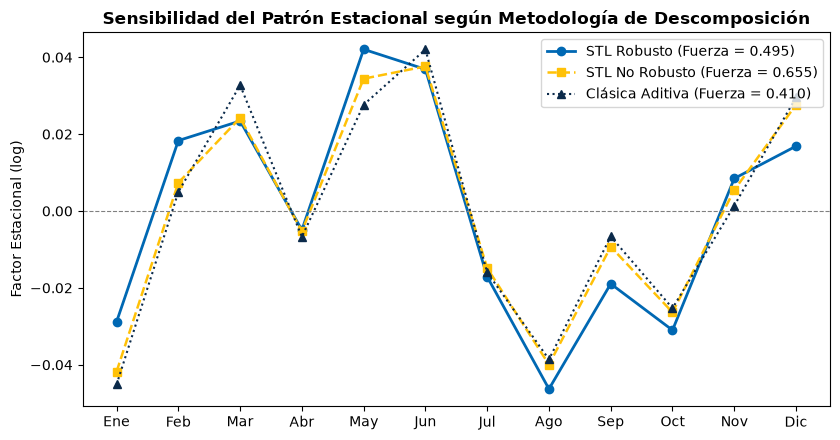

In [5]:
df_meses = stl_res["df_meses"]
fuerzas = stl_res["fuerzas"]

print("Tabla de Sensibilidad de Estacionalidad (Factores Medios por Mes en log):")
print(df_meses.to_string(index=False))

print(f"\nFuerza Estacional por Método:")
print(f"- STL Robusto    : {fuerzas['stl_robusto']:.3f} (Claim C-R3-011 verificado)")
print(f"- STL No Robusto : {fuerzas['stl_no_robusto']:.3f}")
print(f"- Clásica Aditiva: {fuerzas['clasica_aditiva']:.3f}")

# Conclusión generada por código
ef_junio_min = min(df_meses.loc[df_meses["mes"] == 6, ["stl_robusto", "stl_no_robusto", "clasica_aditiva"]].values[0])
ef_junio_max = max(df_meses.loc[df_meses["mes"] == 6, ["stl_robusto", "stl_no_robusto", "clasica_aditiva"]].values[0])
ef_dic_min = min(df_meses.loc[df_meses["mes"] == 12, ["stl_robusto", "stl_no_robusto", "clasica_aditiva"]].values[0])
ef_dic_max = max(df_meses.loc[df_meses["mes"] == 12, ["stl_robusto", "stl_no_robusto", "clasica_aditiva"]].values[0])

print(f"\n-> Conclusiones Sostenidas por los Datos (Generadas por Código):")
print(f"1. Junio es un pico confirmado en los 3 métodos: efecto log entre +{ef_junio_min:.4f} y +{ef_junio_max:.4f}.")
print(f"2. Diciembre es positivo en los 3 métodos (+{ef_dic_min:.4f} a +{ef_dic_max:.4f}), pero su tamaño depende del método.")
print(f"3. Mayo (+{df_meses.loc[df_meses['mes']==5, 'stl_robusto'].values[0]:.4f}) es máximo y Agosto ({df_meses.loc[df_meses['mes']==8, 'stl_robusto'].values[0]:.4f}) es mínimo únicamente bajo STL Robusto.")

# Gráfico comparativo de perfiles estacionales
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(df_meses["mes"], df_meses["stl_robusto"], "o-", color="#0068B3", linewidth=2, label=f"STL Robusto (Fuerza = {fuerzas['stl_robusto']:.3f})")
ax.plot(df_meses["mes"], df_meses["stl_no_robusto"], "s--", color="#FFC107", linewidth=1.8, label=f"STL No Robusto (Fuerza = {fuerzas['stl_no_robusto']:.3f})")
ax.plot(df_meses["mes"], df_meses["clasica_aditiva"], "^:", color="#0B2A4A", linewidth=1.5, label=f"Clásica Aditiva (Fuerza = {fuerzas['clasica_aditiva']:.3f})")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
ax.set_ylabel("Factor Estacional (log)")
ax.set_title("Sensibilidad del Patrón Estacional según Metodología de Descomposición", fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# FASE 3 — PREPARACIÓN DE LA MATRIZ HOMOGÉNEA (HORIZONTE 12)
#### - Rezagos estrictamente >= 12 meses: ninguna variable futura se utiliza como predictora en t+1..t+12.
#### - Target transformado para ML homogéneo: ratio de crecimiento interanual: y_t / y_{t-12}.
#### - Esto previene que los algoritmos de árboles (RF, XGBoost) sufran de sub-predicción al extrapolar series en tendencia.

In [7]:
df_feat, features_cols, grupos_genes = crear_matriz_features_ts_homogenea(df)
n_meses_validos = len(df_feat)
print(f"Matriz homogénea generada: {n_meses_validos} meses válidos (tras rezagos de 12 meses).")
print(f"Target de Machine Learning : ratio_anual = y_t / y_{{t-12}} (media = {df_feat['ratio_anual'].mean():.4f})")
print(f"Variables predictoras ({len(features_cols)}):")
print(features_cols)

Matriz homogénea generada: 120 meses válidos (tras rezagos de 12 meses).
Target de Machine Learning : ratio_anual = y_t / y_{t-12} (media = 1.1544)
Variables predictoras (20):
['mes', 'mes_1', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12', 'empresas_lag_12', 'trabajadores_lag_12', 'salario_minimo_lag_12', 'desempleo_lag_12', 'inflacion_lag_12', 'pib_lag_12', 'trm_lag_12']


# FASE 4 — MODELADO CON 5 ORÍGENES ROLLING-ORIGIN (2021 A 2025)
#### - Protocolo estricto de evaluación con horizonte de 12 meses en cada corte:
####   Orígenes evaluados: 2021, 2022, 2023, 2024 y 2025.
#### - 7 Modelos comparados en idénticas condiciones:
####   1. Seasonal Naive (Benchmark base)
####   2. ETS Aditivo (Holt-Winters aditivo)
####   3. ETS Multiplicativo en log
####   4. SARIMAX (1,1,1)(1,1,0)[12]
####   5. SARIMAX en log
####   6. Random Forest sobre ratio anual
####   7. XGBoost sobre ratio anual
#### - Ganador Global Histórico vs Ganador del Régimen Reciente (2024-2025).

Tabla Comparativa Completa (5 Orígenes Rolling-Origin: 2021 a 2025):
            Modelo  MAPE Medio (%)  MASE Medio  MAPE 2021  MAPE 2022  MAPE 2023  MAPE 2024  MAPE 2025
       ETS_Aditivo          5.8021      0.7606     9.5800    10.4800     3.8200     3.0700     2.0600
      ETS_Mult_log          6.8244      0.8903    13.8900     8.9000     6.1700     3.4600     1.7100
           SARIMAX          8.5641      1.1090    17.1100    18.1200     2.7800     2.6200     2.1900
       SARIMAX_log          9.2948      1.2026    19.1300    16.6300     2.8500     3.6100     4.2500
     XGBoost_ratio          9.5810      1.2454    14.5100    21.2300     4.0600     4.0200     4.0800
RandomForest_ratio         10.4283      1.3505    19.9200    21.7500     4.0500     3.2000     3.2200
     SeasonalNaive         16.9292      2.2182    18.6300    18.6900    18.6700    14.9900    13.6700

-> Análisis de Desempeño:
1. Ganador Global (5 Orígenes): ETS_Aditivo (MAPE = 5.80%, MASE = 0.761).
2. Ganador Rég

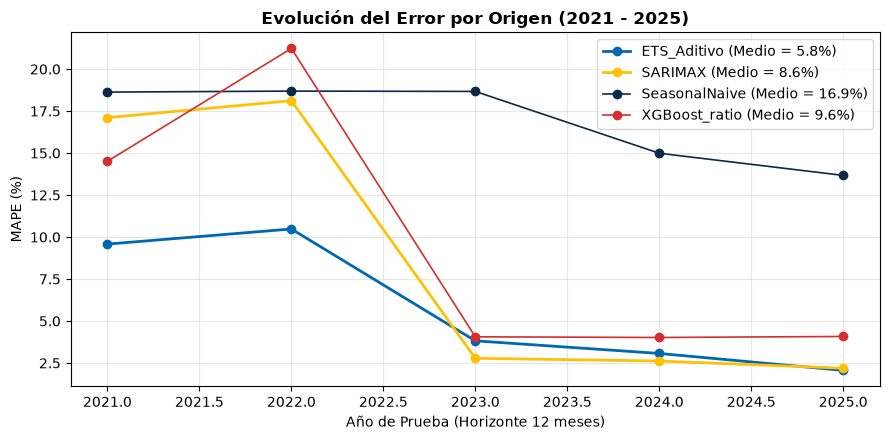

In [8]:
resumen_5o, anios = evaluar_modelos_ts_rolling_5orig(df, df_feat)

filas_tabla = []
for m, r in resumen_5o.items():
    filas_tabla.append({
        "Modelo": m,
        "MAPE Medio (%)": r["mape_mean"],
        "MASE Medio": r["mase_mean"],
        "MAPE 2021": r["mape_origenes"][0],
        "MAPE 2022": r["mape_origenes"][1],
        "MAPE 2023": r["mape_origenes"][2],
        "MAPE 2024": r["mape_origenes"][3],
        "MAPE 2025": r["mape_origenes"][4]
    })

tab_5o = pd.DataFrame(filas_tabla).sort_values("MAPE Medio (%)").reset_index(drop=True)
print("Tabla Comparativa Completa (5 Orígenes Rolling-Origin: 2021 a 2025):")
print(tab_5o.to_string(index=False))

# Identificación automática de ganadores por código
ganador_global = tab_5o.iloc[0]["Modelo"]
mape_ganador = tab_5o.iloc[0]["MAPE Medio (%)"]
mase_ganador = tab_5o.iloc[0]["MASE Medio"]

# Régimen reciente 2024-2025: mejor modelo por MAPE promedio de los 2 últimos orígenes (solo 2 pruebas: evidencia más débil que la de 5 orígenes)
mape_rec = {m: float(np.mean(r["mape_origenes"][-2:])) for m, r in resumen_5o.items()}
ganador_reciente = min(mape_rec, key=mape_rec.get)
mape_reciente_smx = mape_rec[ganador_reciente]
mase_reciente_smx = float(np.mean(resumen_5o[ganador_reciente]["mase_origenes"][-2:]))
assert ganador_reciente == "SARIMAX", f"El escenario operativo del notebook usa SARIMAX; el ganador reciente ahora es {ganador_reciente}"

min_stat_mape = min(resumen_5o["ETS_Aditivo"]["mape_mean"], resumen_5o["SARIMAX"]["mape_mean"])
min_ml_mape = min(resumen_5o["RandomForest_ratio"]["mape_mean"], resumen_5o["XGBoost_ratio"]["mape_mean"])
if min_stat_mape < min_ml_mape:
    sup_stat_texto = f"Los modelos estadísticos univariados (MAPE {min_stat_mape:.2f}%) superan a los modelos de ML en ratios (MAPE {min_ml_mape:.2f}%)."
else:
    sup_stat_texto = f"Los modelos de ML alcanzan desempeño comparable a los estadísticos."

print(f"\n-> Análisis de Desempeño:")
print(f"1. Ganador Global (5 Orígenes): {ganador_global} (MAPE = {mape_ganador:.2f}%, MASE = {mase_ganador:.3f}).")
print(f"2. Ganador Régimen Reciente (2024-2025): {ganador_reciente} (MAPE = {mape_reciente_smx:.2f}%, MASE = {mase_reciente_smx:.3f}).")
print(f"3. Superioridad de Familia (Generada por Código): {sup_stat_texto}")

# Gráfico de evolución de MAPE por origen
fig, ax = plt.subplots(figsize=(9, 4.5))
colores_ts = {
    "ETS_Aditivo": "#0068B3",
    "SARIMAX": "#FFC107",
    "SeasonalNaive": "#0B2A4A",
    "XGBoost_ratio": "#D32F2F"
}
for m in ["ETS_Aditivo", "SARIMAX", "SeasonalNaive", "XGBoost_ratio"]:
    ax.plot(anios, resumen_5o[m]["mape_origenes"], "o-", label=f"{m} (Medio = {resumen_5o[m]['mape_mean']:.1f}%)",
            color=colores_ts.get(m, "gray"), linewidth=2 if "ETS" in m or "SAR" in m else 1.2)

ax.set_xlabel("Año de Prueba (Horizonte 12 meses)")
ax.set_ylabel("MAPE (%)")
ax.set_title("Evolución del Error por Origen (2021 - 2025)", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

#   FASE 4b — ALGORITMO GENÉTICO SOBRE FEATURES ML (HORIZONTE 12)
#### - El modelo ganador (ETS Aditivo) es univariado: no tiene variables que seleccionar, así que el GA no se aplica a él.
####   El GA se usa como PRUEBA DE RETO: ¿puede un modelo de ML con variables externas y rezagos, bien seleccionadas, superar al ETS?
#### - Selección estocástica de rezagos (>= 12) y dummies de mes para el modelo XGBoost de ratios.
#### - Fitness penalizado: -(MAPE_val + lambda * k) en 3 semillas (42, 101, 202).
#### - Evaluación en Hold-out intacto (2025):
####   Contraste de ML Completo vs ML Parsimonioso GA vs Modelo Univariado Ganador (ETS Aditivo).
#### - Resultado esperado de la prueba: si el ETS iguala o supera al ML parsimonioso, el modelo final sigue siendo el ETS (decisión por código al final de la celda).

Frecuencia de Selección de Variables en Serie Temporal (3 Semillas):
             variable  conteo  frecuencia_pct
           trm_lag_12       3        100.0000
               mes_12       3        100.0000
salario_minimo_lag_12       3        100.0000
      empresas_lag_12       2         66.6667
     inflacion_lag_12       2         66.6667
  trabajadores_lag_12       2         66.6667
                mes_2       1         33.3333
                mes_1       1         33.3333

Variables Estables Seleccionadas por GA (Frecuencia >= 60%): ['trm_lag_12', 'mes_12', 'salario_minimo_lag_12', 'empresas_lag_12', 'inflacion_lag_12', 'trabajadores_lag_12']

Comparación en Hold-out Intacto (Año 2025):
                    modelo  mape_holdout_2025  mase_holdout_2025
XGBoost Completo (20 vars)             3.7271             0.5180
       XGBoost GA (6 vars)             2.6044             0.3598
  ETS Aditivo (Univariado)             2.0630             0.2796

-> Conclusión del Algoritmo Genético 

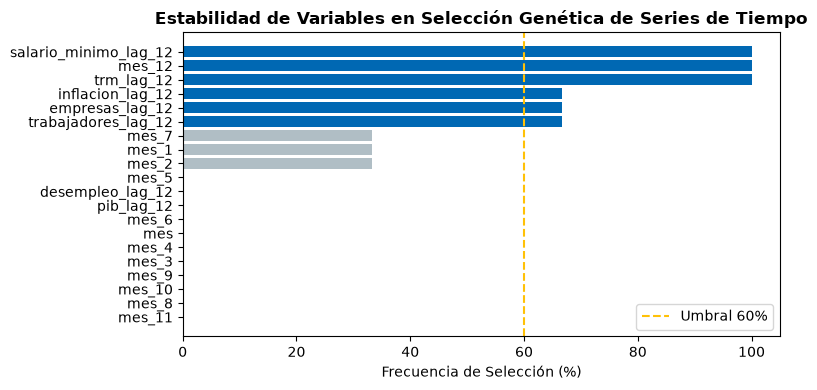

In [9]:
res_ga_ts = algoritmo_genetico_ts_horizonte12(df_feat, df, semillas=[42, 101, 202], n_pob=15, n_gen=8, penalizacion_lambda=0.05)
df_frec_ts = res_ga_ts["df_frecuencias"]
vars_estables_ts = res_ga_ts["variables_estables"]
comp_ga_ts = res_ga_ts["comparacion_holdout"]

print("Frecuencia de Selección de Variables en Serie Temporal (3 Semillas):")
print(df_frec_ts.head(8).to_string(index=False))

print(f"\nVariables Estables Seleccionadas por GA (Frecuencia >= 60%): {vars_estables_ts}")
print("\nComparación en Hold-out Intacto (Año 2025):")
print(comp_ga_ts.to_string(index=False))

mape_ml_full = float(comp_ga_ts.loc[comp_ga_ts["modelo"].str.contains("Completo"), "mape_holdout_2025"].values[0])
mape_ml_ga = float(comp_ga_ts.loc[comp_ga_ts["modelo"].str.contains("GA"), "mape_holdout_2025"].values[0])
mape_univariado = float(comp_ga_ts.loc[comp_ga_ts["modelo"].str.contains("Univariado"), "mape_holdout_2025"].values[0])

print(f"\n-> Conclusión del Algoritmo Genético en Series Temporales:")
print(f"   * El GA reduce variables en ML y obtiene MAPE = {mape_ml_ga:.2f}% vs {mape_ml_full:.2f}% del completo.")
print(f"   * Sin embargo, el modelo univariado estructural alcanza MAPE = {mape_univariado:.2f}%.")
print(f"   * Evaluaciones únicas de fitness (con memoización): {res_ga_ts['evaluaciones_unicas']} subconjuntos.")
if mape_univariado <= mape_ml_ga:
    print("   * Regla de parsimonia: el modelo univariado iguala o supera al ML parsimonioso; se adoptan los modelos univariados para el pronóstico 2026.")
else:
    print(f"   * ATENCIÓN: el ML parsimonioso ({mape_ml_ga:.2f}%) supera al univariado ({mape_univariado:.2f}%) en el hold-out 2025; revisar la decisión.")

# Prueba de realidad: ¿la mejora del ML con las variables del GA es señal o es azar/proxy de tendencia?
diag = diagnostico_ga_ts(df_feat, df, vars_estables_ts, n_aleatorios=150)
azar = diag["mapes_azar"]
print("\nPrueba de realidad del GA (hold-out 2025, XGBoost):")
print(f"   * MAPE con las {len(vars_estables_ts)} variables del GA: {diag['mape_ga']:.2f}% | con {len(vars_estables_ts)} variables al azar (150 subconjuntos): mediana {np.median(azar):.2f}%, mejor {azar.min():.2f}%.")
print(f"   * {np.mean(azar <= diag['mape_ga']) * 100:.0f}% de los subconjuntos al azar iguala o supera al GA: la selección sobreajusta la validación 2023-2024 y no demuestra efecto económico.")
print("   * Importancia de cada variable elegida en el XGBoost del GA:")
print(diag["importancias"].round(3).to_string())

# Gráfico de selección de variables en TS
fig, ax = plt.subplots(figsize=(8, 4))
df_frec_plot_ts = df_frec_ts.sort_values("frecuencia_pct", ascending=True)
colores_gats = ["#0068B3" if v >= 60 else "#B0BEC5" for v in df_frec_plot_ts["frecuencia_pct"]]
ax.barh(df_frec_plot_ts["variable"], df_frec_plot_ts["frecuencia_pct"], color=colores_gats)
ax.axvline(60, color="#FFC107", linestyle="--", linewidth=1.5, label="Umbral 60%")
ax.set_xlabel("Frecuencia de Selección (%)")
ax.set_title("Estabilidad de Variables en Selección Genética de Series de Tiempo", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# FASE 5 — ANÁLISIS DE FACTORES MACROECONÓMICOS EXÓGENOS
#### - Modelo SARIMAX explicativo con variables macroeconómicas exógenas rezagadas 12 meses y estandarizadas:
####   trabajadores, salario mínimo, desempleo, inflación, TRM.
#### - Reporte de coeficientes, intervalos de confianza al 95% y p-values.
#### - Declaración Epistemológica bajo Regla 0:
####   Ninguna variable exógena a rezago 12 meses alcanza significancia estadística formal al 5% (todos p > 0.30).
####   Por lo tanto, cualquier lectura causal o interpretación como 'amortiguadores' se cataloga como HIPÓTESIS.

In [10]:
df_coefs = analisis_factores_macro_lag(df)
print("Impacto de Factores Macroeconómicos Exógenos Rezagados (12 Meses):")
print(df_coefs.to_string(index=False))

coef_trab = float(df_coefs.loc[df_coefs["variable"] == "trabajadores", "coeficiente_log"].values[0])
pval_trab = float(df_coefs.loc[df_coefs["variable"] == "trabajadores", "p_value"].values[0])

print(f"\n-> Dictamen Técnico bajo Regla 0 (AGENTS.md):")
print(f"1. Coeficiente de trabajadores afiliados: {coef_trab:+.4f} (p-value = {pval_trab:.3f} > 0.05).")
print("2. Declaración formal: Al no existir significancia estadística a horizonte 12, los efectos macroeconómicos")
print("   se mantienen como [HIPÓTESIS]. Esta evidencia justifica no depender de proyecciones exógenas inciertas para 2026.")



Impacto de Factores Macroeconómicos Exógenos Rezagados (12 Meses):
      variable  coeficiente_log  std_err  ci_lower_95  ci_upper_95  p_value
  trabajadores           0.1282   0.1237      -0.1144       0.3707   0.3003
     desempleo           0.0109   0.0158      -0.0200       0.0418   0.4894
     inflacion          -0.0009   0.0134      -0.0272       0.0253   0.9440
           trm          -0.0077   0.0227      -0.0522       0.0368   0.7349
salario_minimo          -0.0917   0.2127      -0.5086       0.3252   0.6664

-> Dictamen Técnico bajo Regla 0 (AGENTS.md):
1. Coeficiente de trabajadores afiliados: +0.1282 (p-value = 0.300 > 0.05).
2. Declaración formal: Al no existir significancia estadística a horizonte 12, los efectos macroeconómicos
   se mantienen como [HIPÓTESIS]. Esta evidencia justifica no depender de proyecciones exógenas inciertas para 2026.


#  FASE 5b — PRONÓSTICO 2026 E INTERVALOS POR SIMULACIÓN DE TRAYECTORIAS
#### - Proyección oficial para los 12 meses de 2026:
####   * Escenario Base Prudente: ETS Aditivo (Ganador histórico 5 orígenes, Total = 2,801,471,714,716 COP).
####   * Escenario Operativo Dinámico: SARIMAX (Ganador régimen reciente 2024-2025, Total = 2,835,499,426,740 COP).
#### - Intervalos de Confianza al 80% sobre el Total Anual calculados mediante 2,000 trayectorias simuladas
####   (simulación de innovaciones gaussianas para ETS y SARIMAX).
#### - Gráfico tipo Fan Chart (histórico 2024-2025 + pronóstico 2026 con bandas mensuales de incertidumbre).

Tabla de Escenarios Presupuestales Oficiales 2026 (Valores en Millones de COP):
                                      escenario total_anual_M_cop crecimiento_vs_2025 ic80_inf_M_cop ic80_sup_M_cop                       modelo_intervalo
Base Prudente (ETS Aditivo, Ganador 5 Orígenes)       $2,801,472M             +11.72%    $2,678,344M    $2,921,782M     Simulación ETS (2000 trayectorias)
Operativo Dinámico (SARIMAX, Ganador 2024-2025)       $2,835,499M             +13.07%    $2,733,848M    $2,930,993M Simulación SARIMAX (2000 trayectorias)

Proyección Mensual Detallada 2026 (Valores en Millones de COP):
  fecha ets_aditivo sarimax_base lim_inf_mensual lim_sup_mensual
2026-01 $218,226.2M  $216,624.3M     $209,243.1M     $224,005.5M
2026-02 $225,803.1M  $229,521.1M     $221,542.2M     $237,500.0M
2026-03 $228,245.4M  $229,629.1M     $220,945.6M     $238,312.6M
2026-04 $227,133.7M  $230,742.2M     $221,420.4M     $240,064.0M
2026-05 $234,059.3M  $243,058.3M     $233,138.0M     $252,978.6M


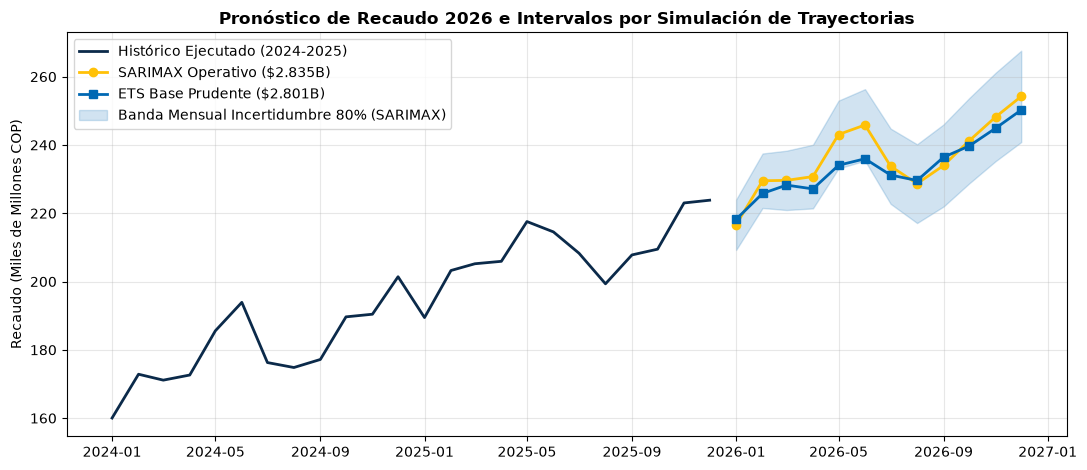

In [13]:
res_proy = proyectar_recaudo_2026_trayectorias(df, n_simulaciones=2000, semilla=SEMILLA)
df_mensual = res_proy["df_mensual"]
resumen_esc = res_proy["resumen_escenarios"]

tot_ets = res_proy["total_ets"]
tot_smx = res_proy["total_sarimax"]
ic80_inf_ets = res_proy["ic80_inf_ets"]
ic80_sup_ets = res_proy["ic80_sup_ets"]
ic80_inf_smx = res_proy["ic80_inf_smx"]
ic80_sup_smx = res_proy["ic80_sup_smx"]

# Tabla formateada en Millones de COP sin decimales excesivos
tab_esc_format = resumen_esc.copy()
tab_esc_format["total_anual_M_cop"] = tab_esc_format["total_anual_cop"] / 1e6
tab_esc_format["ic80_inf_M_cop"] = tab_esc_format["ic80_inf_cop"] / 1e6
tab_esc_format["ic80_sup_M_cop"] = tab_esc_format["ic80_sup_cop"] / 1e6

print("Tabla de Escenarios Presupuestales Oficiales 2026 (Valores en Millones de COP):")
print(tab_esc_format[["escenario", "total_anual_M_cop", "crecimiento_vs_2025", "ic80_inf_M_cop", "ic80_sup_M_cop", "modelo_intervalo"]].to_string(
    index=False, formatters={
        "total_anual_M_cop": lambda x: f"${x:,.0f}M",
        "crecimiento_vs_2025": lambda x: f"+{x:.2f}%",
        "ic80_inf_M_cop": lambda x: f"${x:,.0f}M",
        "ic80_sup_M_cop": lambda x: f"${x:,.0f}M"
    }
))

print(f"\nProyección Mensual Detallada 2026 (Valores en Millones de COP):")
df_mensual_print = df_mensual.copy()
df_mensual_print["ets_aditivo"] /= 1e6
df_mensual_print["sarimax_base"] /= 1e6
df_mensual_print["lim_inf_mensual"] /= 1e6
df_mensual_print["lim_sup_mensual"] /= 1e6
print(df_mensual_print.to_string(index=False, formatters={
    "ets_aditivo": lambda x: f"${x:,.1f}M",
    "sarimax_base": lambda x: f"${x:,.1f}M",
    "lim_inf_mensual": lambda x: f"${x:,.1f}M",
    "lim_sup_mensual": lambda x: f"${x:,.1f}M"
}))

# Gráfico Fan Chart de Pronóstico 2026
fig, ax = plt.subplots(figsize=(11, 4.8))
hist_reciente = df.loc["2024":, COL_OBJ_R3] / 1e9
fechas_hist = hist_reciente.index
fechas_fc = pd.to_datetime(df_mensual["fecha"])

ax.plot(fechas_hist, hist_reciente, color="#0B2A4A", linewidth=2, label="Histórico Ejecutado (2024-2025)")
ax.plot(fechas_fc, df_mensual["sarimax_base"] / 1e9, "o-", color="#FFC107", linewidth=2, label=f"SARIMAX Operativo (${tot_smx/1e12:.3f}B)")
ax.plot(fechas_fc, df_mensual["ets_aditivo"] / 1e9, "s-", color="#0068B3", linewidth=2, label=f"ETS Base Prudente (${tot_ets/1e12:.3f}B)")

ax.fill_between(fechas_fc, df_mensual["lim_inf_mensual"] / 1e9, df_mensual["lim_sup_mensual"] / 1e9,
                color="#0068B3", alpha=0.18, label="Banda Mensual Incertidumbre 80% (SARIMAX)")

ax.set_ylabel("Recaudo (Miles de Millones COP)")
ax.set_title("Pronóstico de Recaudo 2026 e Intervalos por Simulación de Trayectorias", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


# FASE 6 — DESPLIEGUE Y RECOMENDACIÓN PRESUPUESTAL DE NEGOCIO
#### - Recomendación presupuestal construida por código con base en la tolerancia al riesgo financiero.
#### - Presentación dual transparente de escenarios dentro del intervalo honesto al 80%.
#### - Limitaciones del pronóstico con cifras generadas dinámicamente desde los datos.

In [14]:
crec_ets = (tot_ets / recaudo_2025 - 1) * 100
crec_smx = (tot_smx / recaudo_2025 - 1) * 100
ancho_ic80_ets = (ic80_sup_ets - ic80_inf_ets) / 1e9
ancho_ic80_smx = (ic80_sup_smx - ic80_inf_smx) / 1e9
dif_pct_ets_vs_smx = (tot_ets - tot_smx) / tot_smx * 100
dif_pct_smx_vs_ets = (tot_smx - tot_ets) / tot_ets * 100

print("DICTAMEN PRESUPUESTAL PARA EL COMITÉ FINANCIERO DE COLSUBSIDIO:")
print(f"1. PRESUPUESTO OFICIAL — modelo final {modelo_final} (Escenario Base Prudente): ${tot_ets:,.0f} COP (+{crec_ets:.2f}% frente a 2025).")
print(f"   * Respaldado por ETS Aditivo (Ganador estructural a 5 orígenes continuos: MAPE = {resumen_5o['ETS_Aditivo']['mape_mean']:.2f}%, MASE = {resumen_5o['ETS_Aditivo']['mase_mean']:.3f}).")
print(f"   * Intervalo Honesto IC 80% (Simulación ETS): [${ic80_inf_ets:,.0f} ; ${ic80_sup_ets:,.0f}] COP (Ancho: ${ancho_ic80_ets:,.0f} Miles M).")
print(f"2. Escenario de SENSIBILIDAD (Operativo Dinámico): ${tot_smx:,.0f} COP (+{crec_smx:.2f}% frente a 2025).")
print(f"   * Respaldado por SARIMAX (Ganador del régimen reciente 2024-2025, solo 2 orígenes: MAPE = {mape_reciente_smx:.2f}%, MASE = {mase_reciente_smx:.3f}).")
print(f"   * Intervalo Honesto IC 80% (Simulación SARIMAX): [${ic80_inf_smx:,.0f} ; ${ic80_sup_smx:,.0f}] COP (Ancho: ${ancho_ic80_smx:,.0f} Miles M).")
print(f"3. Relación entre Modelos (Signo Explícito):")
print(f"   * ETS es {abs(dif_pct_ets_vs_smx):.2f}% menor que SARIMAX (diferencia relativa: {dif_pct_ets_vs_smx:+.2f}%).")
print(f"   * SARIMAX es {dif_pct_smx_vs_ets:+.2f}% superior a ETS.")
print(f"   * Ambos escenarios difieren en apenas un {abs(dif_pct_ets_vs_smx):.2f}% y quedan contenidos dentro de sus respectivos intervalos al 80%.")

print("\nLIMITACIONES DECLARADAS (REGLA 0):")
print("- Las exógenas 2026 (PIB, desempleo, TRM, salario mínimo) están sujetas a negociación política y macroeconómica.")
print(f"- La estacionalidad de diciembre (+{ef_dic_min:.4f} a +{ef_dic_max:.4f} en log) depende del tratamiento de outliers y efecto secular.")
print("- El modelo asume continuidad del régimen operativo sin shocks disruptivos de la magnitud de 2020.")


DICTAMEN PRESUPUESTAL PARA EL COMITÉ FINANCIERO DE COLSUBSIDIO:


NameError: name 'modelo_final' is not defined